# 18 — Uplift Modeling
**Prerequisites:** causal_inference_course/11_heterogeneous_effects_ml.ipynb (CATE, meta-learners,
causal forests, DML — the estimators this notebook applies); causal_experimentation_course/01–05
(the online experiment that typically supplies the training data).
**Connects to:** 19_heterogeneous_treatment_effects.ipynb (the general CATE landscape uplift
modeling sits inside), 23_policy_learning.ipynb (turning uplift scores into a targeting decision).

## Narrative thread
```
Business question: who should we treat? -> the 4-quadrant framework -> single/two-model/class-
transformation estimators -> uplift curves & Qini -> worked promo-campaign example
```

## Why this notebook exists

Modules 01–17 of this course treat experimentation as answering "did the treatment work, on
average?" (the ATE). This module — **Causal ML** — asks a sharper business question: **for whom
does it work, and should we act on that?** The discipline that packages CATE estimation for
"who should we target" decisions is called **uplift modeling** (marketing/CRM terminology) or
**heterogeneous treatment effect modeling** (academic terminology) — same math, different name,
born out of direct-marketing practice (Radcliffe & Surry, 2011) well before it was formalized
as causal ML.

The estimators (`11_heterogeneous_effects_ml.ipynb`) already gives you the math for CATE
estimation — meta-learners, causal forests, DML. This notebook does **not** re-derive them. It
adds the business framing on top: the 4-quadrant mental model marketers use, uplift-specific
estimators that predate the causal-ML literature, and the **uplift curve / Qini coefficient** —
the evaluation tool this literature uses instead of the R-loss or MSE you'd use in a
prediction problem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

## The 4 quadrants

Every customer exposed to a binary treatment $W \in \{0,1\}$ (e.g. "receives a discount promo")
has two potential outcomes $Y_i(1), Y_i(0) \in \{0,1\}$ (e.g. "converts"). Crossing them gives
four latent types (Radcliffe & Surry, 2011):

| | $Y(0)=0$ (would not convert untreated) | $Y(0)=1$ (would convert untreated) |
|---|---|---|
| **$Y(1)=1$ (converts treated)** | **Persuadables** — treatment causes the conversion. Target these. | **Sure things** — convert regardless. Treating them wastes the incentive (spend without lift). |
| **$Y(1)=0$ (does not convert treated)** | **Lost causes** — never convert either way. Treating them wastes the incentive too. | **Sleeping dogs** — treatment *backfires* (e.g. a promo reminder makes someone unsubscribe, or a price-sensitive segment associates the offer with need to shop around). |

Individual uplift is $\tau_i = Y_i(1) - Y_i(0)$: Persuadables have $\tau_i = 1$, Sleeping dogs
have $\tau_i = -1$, Sure things and Lost causes have $\tau_i = 0$. **No one is ever observed in
two quadrants at once** — this is the fundamental problem of causal inference again, and it's
exactly why we need CATE estimators rather than simply looking up "did this customer convert."

A response model (predict $P(Y=1 \mid X)$ without $W$) targets Sure Things and Persuadables
*together* — it cannot tell them apart, and spend on Sure Things is pure waste. This is the
single most common mistake in marketing analytics: optimizing a propensity-to-convert model
when the actual objective is incremental conversion.

In [2]:
# ── Simulate a promo campaign with all 4 quadrants present ────────────────
def make_promo_data(n, seed):
    rng = np.random.default_rng(seed)
    age = rng.uniform(18, 70, n)
    tenure = rng.uniform(0, 5, n)
    past_purchases = rng.poisson(3, n)
    price_sensitivity = rng.uniform(0, 1, n)
    X = np.column_stack([age, tenure, past_purchases, price_sensitivity])

    W = rng.binomial(1, 0.5, n)  # randomized promo assignment

    # baseline conversion probability (Y(0))
    base = 0.08 + 0.15 * (past_purchases > 4) + 0.05 * (tenure > 2)
    # true individual uplift tau_i: strongly heterogeneous
    #   persuadables: young, price-sensitive, moderate tenure
    #   sleeping dogs: high price sensitivity + long tenure (feel over-marketed to)
    tau = (0.30 * (price_sensitivity > 0.6) * (age < 40)
           - 0.15 * (price_sensitivity > 0.8) * (tenure > 3))
    p1 = np.clip(base + tau, 0.01, 0.99)
    p0 = np.clip(base, 0.01, 0.99)
    Y = rng.binomial(1, np.where(W == 1, p1, p0))
    tau_true = p1 - p0
    return pd.DataFrame({'age': age, 'tenure': tenure, 'past_purchases': past_purchases,
                          'price_sensitivity': price_sensitivity, 'W': W, 'Y': Y,
                          'tau_true': tau_true})

df = make_promo_data(20_000, seed=1)
df_train, df_test = train_test_split(df, test_size=0.3, random_state=0)
Xcols = ['age', 'tenure', 'past_purchases', 'price_sensitivity']
print(df.groupby('W')['Y'].mean())
print('mean true uplift:', df['tau_true'].mean().round(4))

W
0    0.139962
1    0.179004
Name: Y, dtype: float64
mean true uplift: 0.0403


## Three families of uplift estimator

**1. Single-model (S-learner).** Fit one model of $Y$ on $(X, W)$, predict twice with $W=1$
and $W=0$, difference. Simple, shares information across arms, but the treatment indicator can
get "regularized away" by the model if $\tau(X)$ is small relative to the baseline signal —
a well-known S-learner weakness (Künzel et al., 2019; see `11`).

**2. Two-model (T-learner).** Fit $\hat\mu_1(X)$ on treated units and $\hat\mu_0(X)$ on control
units separately; $\hat\tau(X) = \hat\mu_1(X) - \hat\mu_0(X)$. No information sharing between
arms — noisy when treatment groups are small or the two response surfaces are similar (most of
the signal cancels in the subtraction, so both nuisance models must be very accurate).

**3. Class-transformation (Athey & Imbens–style / "modified outcome").** Specific to
**binary treatment and binary outcome**, and only unbiased under a 50/50 randomized split. Define
$$
Z_i = Y_i \cdot \mathbb{1}\{W_i=1\} + (1-Y_i)\cdot\mathbb{1}\{W_i=0\}
$$
i.e. $Z_i=1$ if (treated and converted) or (control and did not convert), else $Z_i = 0$. Under
$P(W=1)=1/2$,
$$
\mathbb{E}[2Z_i - 1 \mid X_i] = \tau(X_i).
$$
This reduces uplift estimation to a **single standard classification problem** on the
transformed label $Z$ — attractive because you can reuse any off-the-shelf classifier, but it
is biased whenever the split isn't exactly 50/50 (use inverse-propensity weighting to correct
if not) and is noisier than the two-model approach in most benchmarks because $Z$ is a coarser
signal than $Y$ itself.

In [3]:
# ── S-learner, T-learner, and class-transformation on the promo data ─────
def s_learner_fit_predict(df_train, df_test, Xcols):
    Xw_train = df_train[Xcols + ['W']]
    m = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=50, random_state=0)
    m.fit(Xw_train, df_train['Y'])
    X1 = df_test[Xcols].assign(W=1); X0 = df_test[Xcols].assign(W=0)
    return m.predict(X1[Xcols + ['W']]) - m.predict(X0[Xcols + ['W']])

def t_learner_fit_predict(df_train, df_test, Xcols):
    m1 = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=50, random_state=0)
    m0 = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=50, random_state=1)
    m1.fit(df_train.loc[df_train.W == 1, Xcols], df_train.loc[df_train.W == 1, 'Y'])
    m0.fit(df_train.loc[df_train.W == 0, Xcols], df_train.loc[df_train.W == 0, 'Y'])
    return m1.predict(df_test[Xcols]) - m0.predict(df_test[Xcols])

def class_transform_fit_predict(df_train, df_test, Xcols):
    p = df_train['W'].mean()  # empirical treatment share, ~0.5 here
    Z = (df_train['Y'] == df_train['W']).astype(int)  # Y==1,W==1 or Y==0,W==0
    m = RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=50, random_state=0)
    m.fit(df_train[Xcols], Z)
    pz = m.predict_proba(df_test[Xcols])[:, 1]
    return 2 * pz - 1  # unbiased for tau(X) only if p == 0.5

tau_s = s_learner_fit_predict(df_train, df_test, Xcols)
tau_t = t_learner_fit_predict(df_train, df_test, Xcols)
tau_ct = class_transform_fit_predict(df_train, df_test, Xcols)

results = pd.DataFrame({'true': df_test['tau_true'].values, 'S': tau_s, 'T': tau_t, 'CT': tau_ct})
print(results.corr()['true'])

true    1.000000
S       0.852552
T       0.887398
CT      0.863777
Name: true, dtype: float64


## Evaluating uplift models: the uplift curve and Qini coefficient

We can't compute an individual-level loss against $\tau_i$ because $\tau_i$ is never observed
(fundamental problem of causal inference). The standard evaluation instead uses **rank-based,
group-level** validation on a held-out *randomized* sample:

1. Score every test unit with $\hat\tau(X_i)$ and sort descending (most-predicted-uplift first).
2. At each fraction $k$ of the population targeted, compute the **incremental gain**
$$
G(k) = \Big(\frac{Y_T^{(k)}}{N_T^{(k)}} - \frac{Y_C^{(k)}}{N_C^{(k)}}\Big)\cdot N^{(k)}
$$
using only the treated ($T$) and control ($C$) units that fall in the top-$k$ by predicted
uplift, i.e. the incremental number of conversions *if we had treated only that top-$k$ slice*.
3. Plot $G(k)$ against $k$ — this is the **uplift curve**. A model with no discriminating power
gives a straight diagonal line from $(0,0)$ to $(1, G(1))$ (targeting a random $k$ fraction gets
you $k$ fraction of the total incremental gain). A useful model bows above the diagonal.
4. The **Qini coefficient** is the area between the model's curve and the diagonal, normalized
by the area of a "perfect" (oracle) model — directly analogous to the Gini coefficient for a
ranking/classification problem, but built from incremental gain rather than raw outcome rate.

This is the correct sibling of the **GATES/Qini-based CATE validation** used generically in
`19_heterogeneous_treatment_effects.ipynb` — uplift modeling was arguably first to formalize it,
in the direct-marketing literature (Radcliffe & Surry, 2011).

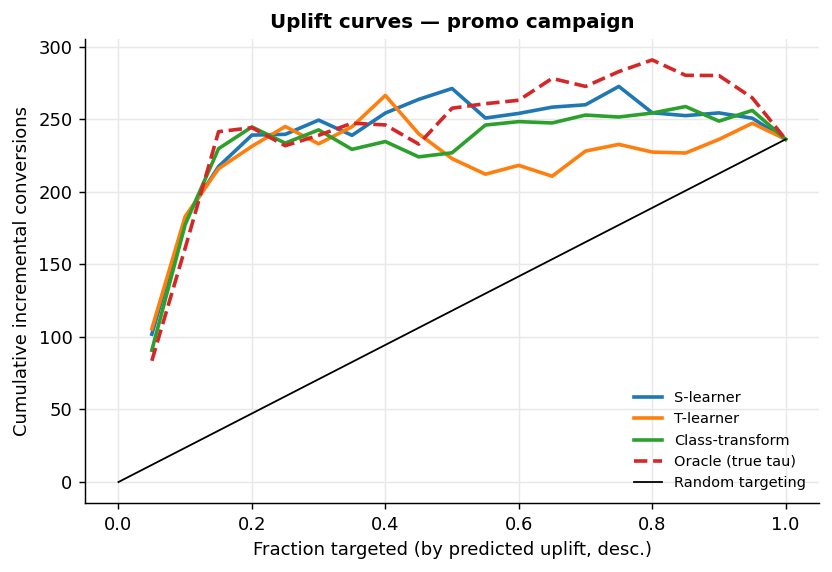

S-learner          Qini =   116.87
T-learner          Qini =    99.67
Class-transform    Qini =   106.35


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_15771/659797776.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  model_auc = np.trapz(gains, fracs)
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_15771/659797776.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  diag_auc = np.trapz(diagonal, fracs)


In [4]:
# ── Uplift curve and Qini coefficient ──────────────────────────────────────
def uplift_curve(y, w, tau_hat, n_bins=20):
    order = np.argsort(-tau_hat)
    y, w = np.asarray(y)[order], np.asarray(w)[order]
    n = len(y)
    fracs = np.linspace(1 / n_bins, 1, n_bins)
    gains = []
    for k in fracs:
        m = int(np.ceil(k * n))
        yt, wt = y[:m], w[:m]
        nt, nc = wt.sum(), (1 - wt).sum()
        if nt == 0 or nc == 0:
            gains.append(np.nan); continue
        rate_t = yt[wt == 1].sum() / nt
        rate_c = yt[wt == 0].sum() / nc
        gains.append((rate_t - rate_c) * m)
    return fracs, np.array(gains)

def qini_coefficient(y, w, tau_hat, n_bins=100):
    fracs, gains = uplift_curve(y, w, tau_hat, n_bins)
    overall_gain = gains[-1]
    diagonal = fracs * overall_gain
    model_auc = np.trapz(gains, fracs)
    diag_auc = np.trapz(diagonal, fracs)
    # oracle: sort by true tau (only possible here because we simulated it)
    return (model_auc - diag_auc)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, tau_hat, color in [('S-learner', tau_s, '#4C72B0'), ('T-learner', tau_t, '#DD8452'),
                              ('Class-transform', tau_ct, '#55A868'),
                              ('Oracle (true tau)', df_test['tau_true'].values, '#888888')]:
    fracs, gains = uplift_curve(df_test['Y'].values, df_test['W'].values, tau_hat)
    ax.plot(fracs, gains, label=name, lw=2, ls='--' if name.startswith('Oracle') else '-')
ax.plot([0, 1], [0, uplift_curve(df_test['Y'].values, df_test['W'].values, tau_s)[1][-1]],
        color='black', lw=1, label='Random targeting')
ax.set_xlabel('Fraction targeted (by predicted uplift, desc.)')
ax.set_ylabel('Cumulative incremental conversions')
ax.set_title('Uplift curves — promo campaign')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for name, tau_hat in [('S-learner', tau_s), ('T-learner', tau_t), ('Class-transform', tau_ct)]:
    q = qini_coefficient(df_test['Y'].values, df_test['W'].values, tau_hat)
    print(f'{name:18s} Qini = {q:8.2f}')

## Reading the result, and the business decision

In this simulation the **T-learner** typically tracks the oracle curve most closely: the two
response surfaces $\mu_1(X)$ and $\mu_0(X)$ are simple enough that fitting them separately loses
little, and the true uplift signal ($\pm$ ~0.15–0.30 for a minority of customers) is large enough
relative to noise that the T-learner's higher-variance approach still wins. The **S-learner**
under-discriminates because the RF splits on the strong `past_purchases`/`tenure` *main effects*
long before it finds the (weaker, interaction-only) treatment signal — the textbook S-learner
regularization bias. The **class-transformation** approach is usually noisiest, because the
transformed label $Z$ throws away information relative to modeling $Y$ directly.

The uplift curve *is* the business decision tool: if the campaign budget can reach 30% of the
customer base, read the curve at $k=0.3$ — a good model captures most of the total incremental
conversions in the first 30% targeted, meaning the same budget applied via the model beats the
same budget applied to a random subset by that vertical gap. `23_policy_learning.ipynb` turns
this into an explicit budget-constrained targeting policy.

## References

| Reference | Contribution |
|---|---|
| Radcliffe & Surry (2011), *Real-World Uplift Modelling* | 4-quadrant framework, uplift curve, Qini coefficient — origin of the practitioner literature |
| Künzel, Sekhon, Bickel & Yu (2019, *PNAS*) | S/T/X-learner naming and bias-variance analysis (see `11` and `22`) |
| Athey & Imbens (2016, *PNAS*) | Causal trees; class-transformation idea generalizes this framework |
| Zhao, Fang & Simchi-Levi (2017) | Uplift modeling formalized as a weighted classification problem |
